Top 10 Highest-Rated Movies:

Inception (2010) - Rating: 8.8
Interstellar (2014) - Rating: 8.6
Whiplash (2014) - Rating: 8.5
Django Unchained (2012) - Rating: 8.4
The Dark Knight Rises (2012) - Rating: 8.4
Toy Story 3 (2010) - Rating: 8.3
Hacksaw Ridge (2016) - Rating: 8.2
Inside Out (2015) - Rating: 8.2
La La Land (2016) - Rating: 8.2
The Wolf of Wall Street (2013) - Rating: 8.2

Rating of Highest-Grossing Movie Worldwide:
Star Wars: The Force Awakens (2015) - Rating: 8.1 Worldwide Gross: $2,068,223,624.0

Distribution of movie ratings: 



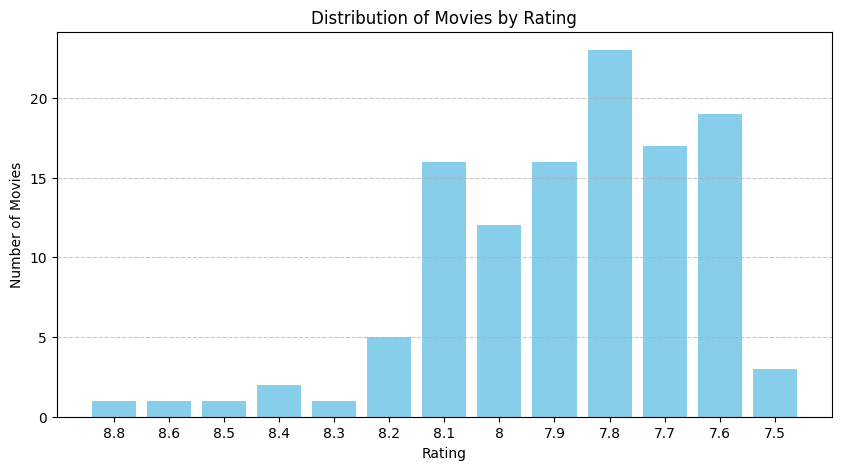


Longest-Running Movie:
The Grand Budapest Hotel (2014) - Runtime: 99 min minutes

Movie with the Highest Net Profit:
Star Wars: The Force Awakens (2015) - Net Profit: $1,823,223,624.0

Least-Budgeted Movie Among the Highest Net-Profit Movies:
Deadpool (2016) - Budget: $58,000,000.0, Net Profit: $725,112,979.0

Percentage of the total budget allocated to each genre, visualized as a bar chart:



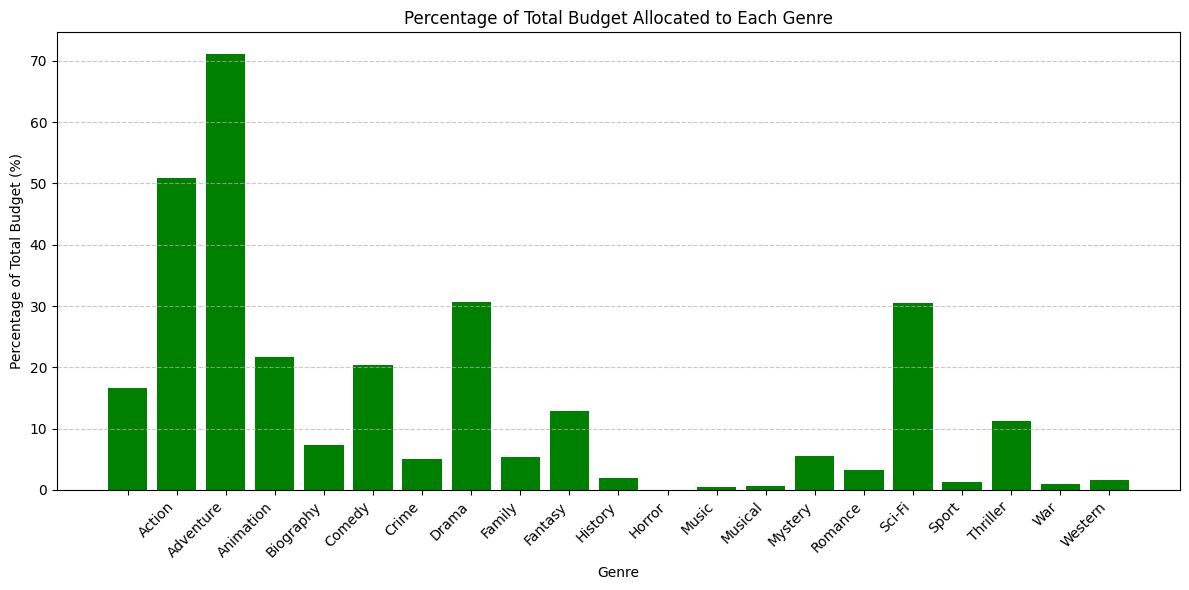


Movies Belonging to Both Action and Adventure Genres (Rating >= 7):

Inception (2010) - Rating: 8.8
How to Train Your Dragon (2010) - Rating: 8.1
Star Wars: The Force Awakens (2015) - Rating: 8.1
Mad Max: Fury Road (2015) - Rating: 8.1
Guardians of the Galaxy (2014) - Rating: 8.1
X-Men: Days of Future Past (2014) - Rating: 8
Deadpool (2016) - Rating: 8
Captain America: Civil War (2016) - Rating: 7.9
Rogue One (2016) - Rating: 7.9
How to Train Your Dragon 2 (2014) - Rating: 7.9
Edge of Tomorrow (2014) - Rating: 7.9
Skyfall (2012) - Rating: 7.8
The Lego Movie (2014) - Rating: 7.8
X-Men: First Class (2011) - Rating: 7.8
Star Trek Into Darkness (2013) - Rating: 7.8
Captain America: The Winter Soldier (2014) - Rating: 7.8
Big Hero 6 (2014) - Rating: 7.8
Kingsman: The Secret Service (2014) - Rating: 7.7
The Hunger Games: Catching Fire (2013) - Rating: 7.6
Doctor Strange (2016) - Rating: 7.6
Dawn of the Planet of the Apes (2014) - Rating: 7.6


In [35]:
import sqlite3  # Import the SQLite library to manage the database
import matplotlib.pyplot as plt  # Importing Matplotlib to plot visualizations

# Connect to SQLite database (will create it if it doesn't exist)
conn = sqlite3.connect('IMDB-movies.sqlite')
cursor = conn.cursor()  # Create a cursor object to execute SQL queries

# Function to display the top 10 highest-rated movies
def top_10():
    # Execute a SQL query to fetch the top 10 movies based on rating
    cursor.execute('''SELECT Title, Rating FROM IMDB ORDER BY Rating DESC LIMIT 10''')
    results = cursor.fetchall()  # Fetch all the results of the query

    # Print the results
    print("Top 10 Highest-Rated Movies:\n")
    for title, rating in results:
        print(f"{title} - Rating: {rating}")

# Function to display the highest-grossing movie's rating
def highest_grossing():
    # Execute a SQL query to find the highest-grossing movie
    cursor.execute('''SELECT IMDB.Title, IMDB.Rating, earning.Worldwide
                      FROM IMDB
                      INNER JOIN earning ON earning.Movie_id = IMDB.Movie_id
                      ORDER BY earning.Worldwide DESC
                      LIMIT 1;''')
    results = cursor.fetchall()  # Fetch the result

    # Print the result
    print("\nRating of Highest-Grossing Movie Worldwide:")
    for title, rating, revenue in results:
        print(f"{title} - Rating: {rating} Worldwide Gross: ${revenue:,}")

# Function to visualize the distribution of movies by their ratings
def distribution():
    # Execute a SQL query to get the count of movies for each rating
    cursor.execute('''SELECT Rating, COUNT(*) as movie_count
                      FROM IMDB
                      GROUP BY Rating
                      ORDER BY Rating DESC''')

    results = cursor.fetchall()  # Fetch all results

    # Extract ratings and movie counts
    ratings = [row[0] for row in results]
    movie_count = [row[1] for row in results]

    # Convert ratings to strings for better visualization
    ratings = list(map(str, ratings))

    # Plot the distribution using a bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(ratings, movie_count, color="skyblue")
    plt.xlabel('Rating')
    plt.ylabel('Number of Movies')
    plt.title('Distribution of Movies by Rating')
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the chart
    plt.show()

# Function to find the longest-running movie
def longest_running():
    # Execute a SQL query to find the movie with the longest runtime
    cursor.execute('''SELECT Title, Runtime
                      FROM IMDB
                      ORDER BY Runtime DESC
                      LIMIT 1;''')
    results = cursor.fetchall()  # Fetch the result

    # Print the result
    print("\nLongest-Running Movie:")
    for title, runtime in results:
        print(f"{title} - Runtime: {runtime} minutes")

# Function to find the movie with the highest net profit
def net_profit():
    # Execute a SQL query to find the movie with the highest net profit
    cursor.execute('''SELECT IMDB.Title,
                      (earning.Worldwide - IMDB.Budget) AS net_profit
                      FROM IMDB
                      INNER JOIN earning ON earning.Movie_id = IMDB.Movie_id
                      ORDER BY net_profit DESC
                      LIMIT 1;''')
    results = cursor.fetchall()  # Fetch the result

    # Print the result
    print("\nMovie with the Highest Net Profit:")
    for title, profit in results:
        print(f"{title} - Net Profit: ${profit:,}")

# Function to find the least-budgeted movie among the highest net-profit movies
def least_budgeted():
    # Execute a SQL query to find the least-budgeted movie among the highest net-profit movies
    cursor.execute('''SELECT IMDB.Title, IMDB.Budget,
                      (earning.Worldwide - IMDB.Budget) AS net_profit
                      FROM IMDB
                      INNER JOIN earning ON earning.Movie_id = IMDB.Movie_id
                      WHERE net_profit > 500000000
                      ORDER BY IMDB.Budget ASC LIMIT 1''')
    results = cursor.fetchall()  # Fetch the result

    # Print the result
    print("\nLeast-Budgeted Movie Among the Highest Net-Profit Movies:")
    for title, budget, profit in results:
        print(f"{title} - Budget: ${budget:,}, Net Profit: ${profit:,}")

# Function to visualize the percentage of total budget allocated to each genre
def percentage_budget():
    # Execute a SQL query to get the total budget for each genre
    cursor.execute('''SELECT genre.Genre, SUM(IMDB.Budget) AS genre_budget
                      FROM IMDB
                      INNER JOIN genre ON IMDB.Movie_id = genre.Movie_id
                      GROUP BY genre.Genre;''')

    results = cursor.fetchall()  # Fetch all results

    # Get the total budget from the database
    cursor.execute('SELECT SUM(Budget) FROM IMDB')
    total_budget = cursor.fetchone()[0]

    # Extract genres and their corresponding budget
    genres = [row[0] for row in results]
    genre_budget = [row[1] for row in results]

    # Calculate the percentage of the total budget allocated to each genre
    percentage_budget = [(budget / total_budget) * 100 for budget in genre_budget]

    # Plot the percentage of the total budget for each genre
    plt.figure(figsize=(12, 6))
    plt.bar(genres, percentage_budget, color="green")
    plt.xlabel('Genre')
    plt.ylabel('Percentage of Total Budget (%)')
    plt.title('Percentage of Total Budget Allocated to Each Genre')

    # Adjust the visualization
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()

    # Show the chart
    plt.show()

# Function to find movies that belong to both Action and Adventure genres with a rating >= 7
def both_genres():
    # Execute a SQL query to find movies that belong to both Action and Adventure genres and have a rating of at least 7
    cursor.execute('''SELECT IMDB.Title,IMDB.Rating
                      FROM IMDB
                      INNER JOIN genre ON genre.Movie_id = IMDB.Movie_id
                      WHERE genre.genre IN ("Action", "Adventure")
                      AND IMDB.Rating >= 7
                      GROUP BY IMDB.Movie_id
                      HAVING COUNT(DISTINCT genre.genre) = 2
                      ORDER BY IMDB.Rating DESC;''')
    results = cursor.fetchall()  # Fetch all results

    # Print the results
    print("\nMovies Belonging to Both Action and Adventure Genres (Rating >= 7):\n")
    for Title, rating in results:
        print(f"{Title} - Rating: {rating}")

# Call the functions to display results
top_10()  # Display top 10 highest-rated movies
highest_grossing()  # Display the highest-grossing movie's rating
print("\nDistribution of movie ratings: \n")
distribution()  # Visualize distribution of movies by rating
longest_running()  # Display the longest-running movie
net_profit()  # Display the movie with the highest net profit
least_budgeted()  # Display the least-budgeted movie among high net-profit movies

# Display the percentage of total budget allocated to each genre
print("\nPercentage of the total budget allocated to each genre, visualized as a bar chart:\n")
percentage_budget()  # Visualize budget allocation by genre
both_genres()  # Display movies in both Action and Adventure genres with a rating >= 7

# Close the database connection
conn.close()


In [36]:
import sqlite3  # Import the SQLite library to manage the database

# Function to create the database and its tables if they don't exist
def create_database():
    with sqlite3.connect("school.db") as connection:
        cursor = connection.cursor()

        # Create the 'teachers' table if it doesn't exist
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS teachers (
            teacher_id INTEGER PRIMARY KEY,
            teacher_name TEXT NOT NULL
        );
        """)

        # Create the 'courses' table, linking to 'teachers' table via teacher_id
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS courses (
            course_id INTEGER PRIMARY KEY,
            teacher_id INTEGER,
            course_name TEXT NOT NULL,
            FOREIGN KEY (teacher_id) REFERENCES teachers(teacher_id)
        );
        """)

        # Create the 'students' table if it doesn't exist
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS students (
            student_id INTEGER PRIMARY KEY,
            student_name TEXT NOT NULL
        );
        """)

        # Create the 'student_courses' table to link students to courses
        cursor.execute("""
        CREATE TABLE IF NOT EXISTS student_courses (
            course_id INTEGER,
            student_id INTEGER,
            PRIMARY KEY (course_id, student_id),
            FOREIGN KEY (course_id) REFERENCES courses(course_id),
            FOREIGN KEY (student_id) REFERENCES students(student_id)
        );
        """)

# Function to insert data into a specified table with dynamic columns
def insert_data(table, **values):
    with sqlite3.connect("school.db") as connection:
        cursor = connection.cursor()
        # Prepare the columns and placeholders for the SQL query
        columns = ', '.join(values.keys())
        placeholders = ', '.join(['?'] * len(values))
        # Execute the INSERT SQL query
        cursor.execute(f"INSERT INTO {table} ({columns}) VALUES ({placeholders})", tuple(values.values()))
        connection.commit()

# Function to get the ID of a student or course based on the name
def get_id(table, name, column):
    with sqlite3.connect("school.db") as connection:
        cursor = connection.cursor()
        # Query to get the student_id or course_id based on the table and name
        if table == "students":
            cursor.execute("SELECT student_id FROM students WHERE student_name = ?", (name,))
        elif table == "courses":
            cursor.execute("SELECT course_id FROM courses WHERE course_name = ?", (name,))
        else:
            return None
        result = cursor.fetchone()  # Fetch the result
        return result[0] if result else None  # Return ID or None if not found

# Function to enroll a student in a course
def enroll_student_in_course(student_name, course_name):
    # Get the student_id and course_id using the get_id function
    student_id = get_id('students', student_name, 'student')
    course_id = get_id('courses', course_name, 'course')

    if student_id and course_id:
        with sqlite3.connect("school.db") as connection:
            cursor = connection.cursor()
            # Insert into the student_courses table to enroll the student
            cursor.execute("INSERT OR IGNORE INTO student_courses (student_id, course_id) VALUES (?, ?)", (student_id, course_id))
            connection.commit()
        print(f"Student '{student_name}' enrolled in course '{course_name}' successfully.")
    else:
        print(f"Error: student or course not found.")

# Function to get a list of courses a student is enrolled in
def get_student_courses(student_name):
    student_id = get_id('students', student_name, 'student')
    if student_id:
        with sqlite3.connect("school.db") as connection:
            cursor = connection.cursor()
            # Query to get courses a student is enrolled in
            cursor.execute("""
            SELECT courses.course_name
            FROM student_courses
            JOIN courses ON student_courses.course_id = courses.course_id
            WHERE student_courses.student_id = ?
            """, (student_id,))
            courses = cursor.fetchall()  # Fetch all courses for the student
        return [course[0] for course in courses]  # Return a list of course names
    return []  # Return empty list if no student found

# Main function to run the interactive menu system
def main():
    create_database()  # Create the database and tables

    while True:
        print("\nMenu:")  # Display menu options
        print("1. Add a new course")
        print("2. Add a new student")
        print("3. Enroll a student in a course")
        print("4. List courses for a student")
        print("5. Exit")

        choice = input("Choose an option: ")  # Get user input for menu option

        # Option 1: Add a new course
        if choice == "1":
            course_name = input("Enter course name: ")
            teacher_id = input("Enter teacher ID (optional, press Enter to skip): ") or None
            insert_data("courses", course_name=course_name, teacher_id=teacher_id)  # Insert course data
            print("Course added successfully.")

        # Option 2: Add a new student
        elif choice == "2":
            student_name = input("Enter student name: ")
            insert_data("students", student_name=student_name)  # Insert student data
            print(f"Student '{student_name}' added successfully.")

        # Option 3: Enroll a student in a course
        elif choice == "3":
            student_name = input("Enter student name: ")
            course_name = input("Enter course name: ")
            enroll_student_in_course(student_name, course_name)  # Enroll student in course

        # Option 4: List courses for a student
        elif choice == "4":
            student_name = input("Enter student name: ")
            courses = get_student_courses(student_name)  # Get student's courses
            if courses:
                print("Courses enrolled:", ", ".join(courses))  # Display enrolled courses
            else:
                print("No courses found for this student.")

        # Option 5: Exit the program
        elif choice == "5":
            print("Exiting program.")
            break

        else:
            print("Invalid option. Please try again.")  # Handle invalid input

# Run the main function to start the program
main()



Menu:
1. Add a new course
2. Add a new student
3. Enroll a student in a course
4. List courses for a student
5. Exit
Choose an option: 1
Enter course name: mates
Enter teacher ID (optional, press Enter to skip): 
Course added successfully.

Menu:
1. Add a new course
2. Add a new student
3. Enroll a student in a course
4. List courses for a student
5. Exit
Choose an option: 2
Enter student name: bea
Student 'bea' added successfully.

Menu:
1. Add a new course
2. Add a new student
3. Enroll a student in a course
4. List courses for a student
5. Exit
Choose an option: mates
Invalid option. Please try again.

Menu:
1. Add a new course
2. Add a new student
3. Enroll a student in a course
4. List courses for a student
5. Exit
Choose an option: 3
Enter student name: bea
Enter course name: mates
Student 'bea' enrolled in course 'mates' successfully.

Menu:
1. Add a new course
2. Add a new student
3. Enroll a student in a course
4. List courses for a student
5. Exit
Choose an option: 4
Enter s